In [24]:
import gc
import os
import sys
from datetime import timedelta
from itertools import combinations
from pathlib import Path

import jdatetime
import numpy as np
import pandas as pd

In [25]:
# Add src to path to import project modules
sys.path.insert(0, str(Path.cwd().parent / "src"))

from instruments import InstrumentRegistry

# Load the instrument registry from data/instruments.yaml
registry = InstrumentRegistry()

instruments = [inst for inst in registry]

instruments

[Instrument(isin='IRTKMOFD0001', ins_code='34144395039913458', symbol='ayar', name='sandogh talaye ayar mofid'),
 Instrument(isin='IRTKROBA0001', ins_code='25559236668122210', symbol='kahroba', name='kahroba - sandogh s. kalaye kahroba'),
 Instrument(isin='IRTKZARA0001', ins_code='32469128621155736', symbol='mesghal', name='mesghalsandogh s. kalaye agah'),
 Instrument(isin='IRTKLOTF0001', ins_code='46700660505281786', symbol='lotous', name='sandogh s.poshtvaneh talaye lotous (tala). sandogh-haye kalayi'),
 Instrument(isin='IRTKGANJ0001', ins_code='58514988269776425', symbol='ganj', name='sandogh simaye kardan'),
 Instrument(isin='IRTKKIAN0001', ins_code='12390706505809150', symbol='gohar', name='sandogh talaye kian'),
 Instrument(isin='IRTKJAVA0001', ins_code='38544104313215500', symbol='javaher', name='sandogh talaye denaye zagros'),
 Instrument(isin='IRTKTABA0001', ins_code='9089296888187061', symbol='tabesh', name='sandogh taban tamadon'),
 Instrument(isin='IRTKZARF0001', ins_code='

In [26]:
def jalali_daterange(start: str, end: str) -> list[str]:
    """Generate list of Jalali dates from start → end (inclusive).
    
    Args:
        start: Jalali date string (YYYY-MM-DD)
        end: Jalali date string (YYYY-MM-DD)
    
    Returns:
        List of date strings in YYYY-MM-DD format
    """
    sy, sm, sd = (int(x) for x in start.split("-"))
    ey, em, ed = (int(x) for x in end.split("-"))
    cur = jdatetime.date(sy, sm, sd)
    last = jdatetime.date(ey, em, ed)
    
    if cur > last:
        raise ValueError(f"Start date {start} is after end date {end}")
    
    dates = []
    while cur <= last:
        dates.append(f"{cur.year:04d}-{cur.month:02d}-{cur.day:02d}")
        cur += timedelta(days=1)
    
    return dates

In [27]:
# Lookup instrument metadata for a parquet file
def load_with_metadata(file_path: str | Path):
    """Load parquet and enrich with instrument metadata from registry."""
    file_path = Path(file_path)
    
    # Extract ISIN from filename: {isin}_{jalali_date}.parquet
    filename_stem = file_path.stem  # removes .parquet
    isin = filename_stem.split("_")[0]
    
    # Load the dataframe
    df = load_parquet(file_path)
    
    # Lookup instrument in registry
    try:
        inst = registry.by_isin(isin)
        return df, inst
    except KeyError as e:
        print(f"⚠️  Warning: {e}")
        return df, None

In [28]:
def load_parquet(file_path: str | Path) -> pd.DataFrame:
    """
    Load a Parquet file into a pandas DataFrame.

    Args:
        file_path: Path to the .parquet file (string or Path object)

    Returns:
        pandas DataFrame with the data

    Raises:
        FileNotFoundError: If the file doesn't exist
        Exception: If the file can't be read as Parquet
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if not file_path.suffix == ".parquet":
        raise ValueError(f"Expected .parquet file, got: {file_path.suffix}")

    try:
        return pd.read_parquet(file_path)
    except Exception as e:
        raise Exception(f"Failed to read {file_path}: {e}")


def load_orderbook_parquet(file_path: str | Path) -> pd.DataFrame:
    """Load an orderbook Parquet file and return as DataFrame."""
    df = load_parquet(file_path)
    # Orderbooks have 'time' + depth level columns
    return df


def load_trades_parquet(file_path: str | Path) -> pd.DataFrame:
    """Load a trades Parquet file and return as DataFrame."""
    df = load_parquet(file_path)
    # Trades have nTran, hEven, volume, price, canceled columns
    return df

In [29]:
ORDERBOOK_DIR = "../data/orderbooks"

def get_instrument_orderbook_file_path(inst , date):
    filename = f"{inst.isin:12}_{date}.parquet"
    return os.path.join(ORDERBOOK_DIR, filename)

In [30]:
date_range = jalali_daterange("1404-08-01", "1404-12-07")

In [9]:
def load_orderbook_chunks(date_range, registry, chunk_size=10):
    """
    Generator that loads orderbook data chunk by chunk.
    Yields one pandas DataFrame per chunk of dates.
    """
    all_dates = list(date_range)
    chunks    = [all_dates[i:i+chunk_size] for i in range(0, len(all_dates), chunk_size)]

    for chunk_idx, chunk_dates in enumerate(chunks):
        print(f"chunk {chunk_idx+1}/{len(chunks)}: {chunk_dates[0]} → {chunk_dates[-1]}")

        records = []

        for date in chunk_dates:
            for inst in registry:
                path = get_instrument_orderbook_file_path(inst, date)

                if not os.path.exists(path):
                    continue

                df = load_orderbook_parquet(path)

                if df.empty:
                    continue

                cols = ['time']
                for i in range(1, 6):
                    cols += [
                        f'buy_count_{i}',
                        f'buy_volume_{i}',
                        f'buy_price_{i}',
                        f'sell_price_{i}',
                        f'sell_volume_{i}',
                        f'sell_count_{i}',
                    ]

                df = df[cols]
                df['mid']  = (df['buy_price_1'] + df['sell_price_1']) / 2
                df['date'] = date
                df['isin'] = inst.isin
                records.append(df)

        if not records:
            continue

        chunk_df = (
            pd.concat(records, ignore_index=True)
            .set_index(['date', 'isin', 'time'])
            .sort_index()
        )

        yield chunk_df

        # free memory after yield
        del records, chunk_df
        gc.collect()

In [11]:
CHUNK_SIZE = 10
OUT        = "../data/log_ratios"
os.makedirs(OUT, exist_ok=True)

In [12]:
CHUNK_SIZE = 10

isins     = [inst.isin for inst in registry]
all_pairs = list(combinations(isins, 2))

all_log_ratios = []

for chunk_df in load_orderbook_chunks(date_range, registry, chunk_size=CHUNK_SIZE):

    chunk_ratios = {}

    for isin_a, isin_b in all_pairs:
        pair = f"{isin_a}/{isin_b}"

        try:
            price_a = chunk_df.xs(isin_a, level='isin')['mid']
            price_b = chunk_df.xs(isin_b, level='isin')['mid']
        except KeyError:
            continue

        price_a, price_b = price_a.align(price_b, join='inner')
        mask    = price_a.notna() & price_b.notna()
        price_a = price_a[mask]
        price_b = price_b[mask]

        if len(price_a) == 0:
            continue

        chunk_ratios[pair] = np.log(price_a) - np.log(price_b)

    # build chunk dataframe — rows=(date,time), columns=pairs
    chunk_ratio_df = pd.DataFrame(chunk_ratios)
    chunk_ratio_df.index.names = ['date', 'time']
    all_log_ratios.append(chunk_ratio_df)

    del chunk_ratios, chunk_ratio_df
    gc.collect()

# final concat
log_ratios_df = pd.concat(all_log_ratios).sort_index()

del all_log_ratios
gc.collect()

chunk 1/13: 1404-08-01 → 1404-08-10
✓ Loaded IRTKMOFD0001_1404-08-01.parquet
  Shape: (0, 31)
  Columns: time, buy_count_1, buy_volume_1, buy_price_1, sell_price_1, sell_volume_1, sell_count_1, buy_count_2, buy_volume_2, buy_price_2, sell_price_2, sell_volume_2, sell_count_2, buy_count_3, buy_volume_3, buy_price_3, sell_price_3, sell_volume_3, sell_count_3, buy_count_4, buy_volume_4, buy_price_4, sell_price_4, sell_volume_4, sell_count_4, buy_count_5, buy_volume_5, buy_price_5, sell_price_5, sell_volume_5, sell_count_5
✓ Loaded IRTKROBA0001_1404-08-01.parquet
  Shape: (0, 31)
  Columns: time, buy_count_1, buy_volume_1, buy_price_1, sell_price_1, sell_volume_1, sell_count_1, buy_count_2, buy_volume_2, buy_price_2, sell_price_2, sell_volume_2, sell_count_2, buy_count_3, buy_volume_3, buy_price_3, sell_price_3, sell_volume_3, sell_count_3, buy_count_4, buy_volume_4, buy_price_4, sell_price_4, sell_volume_4, sell_count_4, buy_count_5, buy_volume_5, buy_price_5, sell_price_5, sell_volume_5,

0

In [21]:
log_ratios_df.to_csv("../data/log_ratios.csv")

In [23]:
log_ratios_df.info()

<class 'pandas.DataFrame'>
MultiIndex: 3664695 entries, ('1404-08-03', '06:01:25') to ('1404-12-06', '18:00:00')
Columns: 136 entries, IRTKMOFD0001/IRTKROBA0001 to IRTKZOMR0001/IRTKROSE0001
dtypes: float64(136)
memory usage: 3.7 GB


In [31]:
import os
import pandas as pd
from collections import defaultdict

ORDERBOOK_DIR = "../data/orderbooks"

issues = []

for filename in sorted(os.listdir(ORDERBOOK_DIR)):
    if not filename.endswith(".parquet"):
        continue

    path = os.path.join(ORDERBOOK_DIR, filename)
    isin, date = filename.replace(".parquet", "").split("_", 1)

    df = pd.read_parquet(path, columns=['time'])

    if df.empty:
        continue

    # convert time to datetime for diff computation
    times = pd.to_datetime(df['time'].astype(str), format='%H:%M:%S')
    diffs = times.diff().dropna()

    # check for non-1-second gaps
    non_one_second = diffs[diffs != pd.Timedelta(seconds=1)]

    if len(non_one_second) > 0:
        issues.append({
            'file':             filename,
            'isin':             isin,
            'date':             date,
            'total_rows':       len(df),
            'non_1s_gaps':      len(non_one_second),
            'min_gap':          diffs.min(),
            'max_gap':          diffs.max(),
            'pct_non_1s':       round(len(non_one_second) / len(diffs) * 100, 2),
        })

issues_df = pd.DataFrame(issues)

if issues_df.empty:
    print("✓ all files have 1-second intervals")
else:
    print(f"✗ {len(issues_df)} files have non-1-second gaps")
    print(issues_df.sort_values('pct_non_1s', ascending=False).to_string())

✓ all files have 1-second intervals


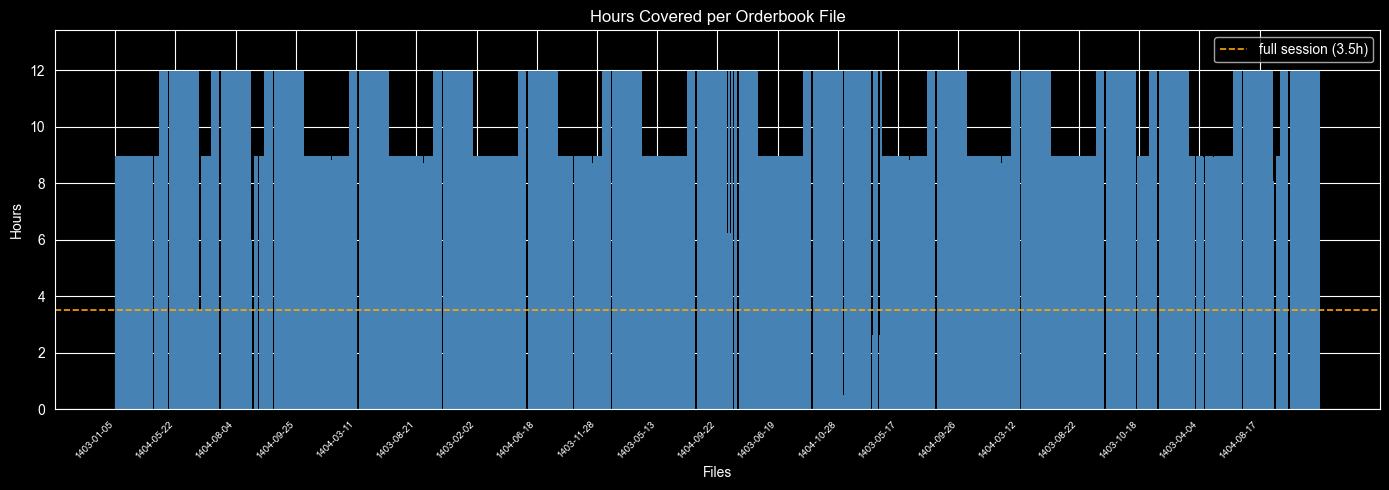

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt

ORDERBOOK_DIR = "../data/orderbooks"

coverage = []

for filename in sorted(os.listdir(ORDERBOOK_DIR)):
    if not filename.endswith(".parquet"):
        continue

    path = os.path.join(ORDERBOOK_DIR, filename)
    isin, date = filename.replace(".parquet", "").split("_", 1)

    df = pd.read_parquet(path, columns=['time'])

    if df.empty:
        continue

    hours_covered = len(df) / 3600   # 1 row = 1 second

    coverage.append({
        'isin': isin,
        'date': date,
        'hours': round(hours_covered, 2),
    })

coverage_df = pd.DataFrame(coverage)

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    range(len(coverage_df)),
    coverage_df['hours'],
    color='steelblue',
    width=1.0,
    edgecolor='none',
)

ax.axhline(3.5, color='orange', linewidth=1.2, linestyle='--', label='full session (3.5h)')

ax.set_title("Hours Covered per Orderbook File")
ax.set_ylabel("Hours")
ax.set_xlabel("Files")
ax.legend()

# x ticks — show only every N files to avoid overlap
tick_step = max(1, len(coverage_df) // 20)
ax.set_xticks(range(0, len(coverage_df), tick_step))
ax.set_xticklabels(
    coverage_df['date'].iloc[::tick_step],
    rotation=45, ha='right', fontsize=7
)

plt.tight_layout()
plt.savefig("coverage_hours.png", dpi=150, bbox_inches='tight')
plt.show()

In [33]:
coverage_df

,isin,date,hours
0,IRTKALTN0001,1403-01-05,8.98
1,IRTKALTN0001,1403-01-06,8.98
2,IRTKALTN0001,1403-01-07,8.98
3,IRTKALTN0001,1403-01-08,8.98
4,IRTKALTN0001,1403-01-11,8.97
...,...,...,...
6615,IRTKZOMR0001,1404-12-02,11.98
6616,IRTKZOMR0001,1404-12-03,11.97
6617,IRTKZOMR0001,1404-12-04,11.98
6618,IRTKZOMR0001,1404-12-05,11.98


In [34]:
bins   = [0, 8, 9, 10, 11, 12, float('inf')]
labels = ['<8h', '8-9h', '9-10h', '10-11h', '11-12h', '>12h']

coverage_df['hour_bucket'] = pd.cut(coverage_df['hours'], bins=bins, labels=labels)

summary = coverage_df['hour_bucket'].value_counts().sort_index()
print(summary)

hour_bucket
<8h         47
8-9h      2847
9-10h        1
10-11h       0
11-12h    3508
>12h         2
Name: count, dtype: int64
